<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day14_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DMML Day 14 Lab: Naive Bayes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1jsazLeOrMKG4IJJ6-KpoGmxUdex6qPoJ')
df

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,non-mammals
2,salmon,0,0,1,0,0,0,non-mammals
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,non-mammals
5,komodo,0,0,0,0,1,0,non-mammals
6,bat,1,1,0,1,1,1,mammals
7,pigeon,1,0,0,1,1,0,non-mammals
8,cat,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,non-mammals


In [3]:
df['Class'].value_counts()

,count
Class,
non-mammals,10
mammals,5


First we’ll try Naive Bayes by hand to predict a new example’s class.
“By hand” means you can manually count things and do math with a calculator, or use pandas/numpy to count things and do math.
Let's figure out which way a flying squirrel would be classified. Assume that attribute values would be:
Warm-blooded: 1
Gives Birth: 1
Aquatic Creature: 0
Aerial Creature: 1
Has Legs: 1
Hibernates: 0
Following the examples in the slides, calculate the following probabilities, showing your work. (Note that this dataset is slightly different from the example in the slides.)
P(Class = M | A = [1, 1, 0, 1, 1, 0])
If things are going well, this should be 0.0256
P(Class = N | A = [1, 1, 0, 1, 1, 0])
Which class would be predicted for the new flying squirrel example? Show your work in your notebook.


In [4]:
p_m = 5/15
p_n = 10/15

# P(Class = M | A = [1, 1, 0, 1, 1, 0])

# P(WB=1 | M)
mask = (df['Class'] == 'mammals') & (df['Warm-blooded'] == 1)
print(mask.sum(), "/ 5")

# P(GB=1 | M)
mask = (df['Class'] == 'mammals') & (df['Gives Birth'] == 1)
print(mask.sum(), "/ 5")

# P(AqC=0 | M)
mask = (df['Class'] == 'mammals') & (df['Aquatic Creature'] == 0)
print(mask.sum(), "/ 5")

# P(AeC=1 | M)
mask = (df['Class'] == 'mammals') & (df['Aerial Creature'] == 1)
print(mask.sum(), "/ 5")

# P(HL = 1 | M)
mask = (df['Class'] == 'mammals') & (df['Has Legs'] == 1)
print(mask.sum(), "/ 5")

# P(H = 0 | M)
mask = (df['Class'] == 'mammals') & (df['Hibernates'] == 0)
print(mask.sum(), "/ 5")



5 / 5
5 / 5
4 / 5
1 / 5
4 / 5
3 / 5


P(M | 1, 1, 0, 1, 1, 0) = P(1, 1, 0, 1, 1, 0 | M) P(M)

In [5]:
5/5 * 5/5 * 4/5 * 1/5 * 4/5 * 3/5 * p_m

0.0256

## Now for non-mammals
P(N | 1, 1, 0, 1, 1, 0) = P(1, 1, 0, 1, 1, 0 | N) P(N)

In [6]:
p_n = 10/15

# P(Class = N | A = [1, 1, 0, 1, 1, 0])

# P(WB=1 | N)
mask = (df['Class'] == 'non-mammals') & (df['Warm-blooded'] == 1)
print(mask.sum(), "/ 10")

# P(GB=1 | N)
mask = (df['Class'] == 'non-mammals') & (df['Gives Birth'] == 1)
print(mask.sum(), "/ 10")

# P(AqC=0 | N)
mask = (df['Class'] == 'non-mammals') & (df['Aquatic Creature'] == 0)
print(mask.sum(), "/ 10")

# P(AeC=1 | N)
mask = (df['Class'] == 'non-mammals') & (df['Aerial Creature'] == 1)
print(mask.sum(), "/ 10")

# P(HL = 1 | N)
mask = (df['Class'] == 'non-mammals') & (df['Has Legs'] == 1)
print(mask.sum(), "/ 10")

# P(H = 0 | N)
mask = (df['Class'] == 'non-mammals') & (df['Hibernates'] == 0)
print(mask.sum(), "/ 10")

2/10 * 1/10 * 3/10 * 1/10 * 6/10 * 7/10 * p_n

2 / 10
1 / 10
3 / 10
1 / 10
6 / 10
7 / 10


0.000168

## Train a classifier
Fit a Naive Bayes classifier to the data. The version we’ll use is called Gaussian Naive Bayes, or GaussianNB in SciKit Learn. Some key points:
We’ll use all the data as training, and make up some test data later. We want to predict mammal or not using the other columns.
You can double-check that the model is reasonable by seeing if the prior probabilities match your manual calculations. If not, there’s probably an error either in your calculations or in your model building. Note that the prior probabilities are not the whole calculation you did above, just part of it, i.e., P(class = M) and P(class = N). See slides for more about prior probabilities.


In [7]:
Xtrain = df.drop(['Name', 'Class'], axis=1)
ytrain = df['Class']

model = GaussianNB()
model = model.fit(Xtrain, ytrain)


In [8]:
model.classes_

array(['mammals', 'non-mammals'], dtype='<U11')

In [9]:
model.class_prior_

array([0.33333333, 0.66666667])

## Test data

In [10]:
testData = [
    ['gila monster', 0, 0, 0, 0, 1, 1, 'non-mammals'],
    ['platypus', 1, 0, 0, 0, 1, 1, 'mammals'],
    ['owl', 1, 0, 0, 1, 1, 0, 'non-mammals'],
    ['dolphin', 1, 1, 1, 0, 0, 0, 'mammals']
]

testData = pd.DataFrame(testData, columns=df.columns)
testData

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,gila monster,0,0,0,0,1,1,non-mammals
1,platypus,1,0,0,0,1,1,mammals
2,owl,1,0,0,1,1,0,non-mammals
3,dolphin,1,1,1,0,0,0,mammals


In [11]:
Xtest = testData.drop(['Name', 'Class'], axis=1)
ytest = testData['Class']

In [12]:
ypred = model.predict(Xtest)

display(testData)
print()
print('predictions: ', ypred)

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,gila monster,0,0,0,0,1,1,non-mammals
1,platypus,1,0,0,0,1,1,mammals
2,owl,1,0,0,1,1,0,non-mammals
3,dolphin,1,1,1,0,0,0,mammals



predictions:  ['non-mammals' 'non-mammals' 'non-mammals' 'mammals']


In [13]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

     mammals       1.00      0.50      0.67         2
 non-mammals       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



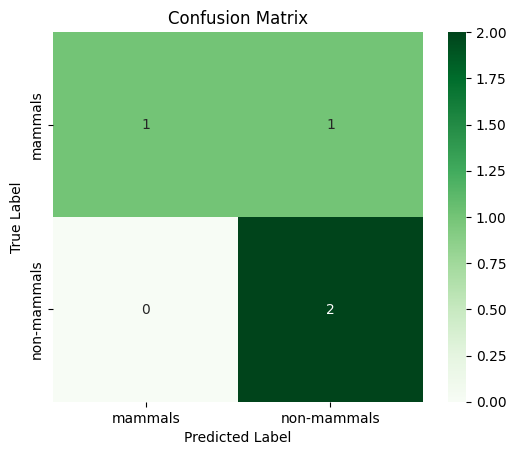

In [14]:
classes = ytrain.unique()
cm = confusion_matrix(ytest, ypred, labels=classes)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                    cmap="Greens",
                    xticklabels=classes,
                    yticklabels=classes)

plt.xlabel('Predicted Label');
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
